# Plasmid typing — replicons & a deep dive on MOB-suite

**Authoritative typing** of the 208,248-plasmid working set:
- **PlasmidFinder** replicon/Inc typing at the standard **≥80% identity / ≥60% coverage** (§1).
- **MOB-suite `mob_typer`** on **all 208,245** sequenced plasmids — this notebook analyses that output in
  depth: mobility and its molecular determinants, conjugation systems (relaxase × MPF), MOB clusters,
  predicted host range & breadth, and sequence novelty (§2–6).

Method & compute: `reports/typing_methodology.md`. Reads the master (`pf_*` columns) and the full
MOB-suite table `data/plasmidscope_primary/mob_full.tsv.gz`. Built by `scripts/build_typing_notebook.py`.

**Caveats.** 20% PlasmidFinder replicon coverage is biology — most metagenomic plasmids carry no
typeable replicon. `mob_host_range` is a coarse taxonomic-convergence prediction; `mash_neighbor_distance`
is distance to MOB-suite's reference set (a proxy for novelty, not a phylogeny).

## 0 · Setup

In [1]:
import os, re
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib as mpl, matplotlib.pyplot as plt

while not Path("data/plasmidscope_primary/plasmid_metadata_master.tsv").exists() and Path.cwd() != Path.cwd().parent:
    os.chdir("..")
pd.set_option("display.width", 150)
FIG = Path("reports/figures/typing"); FIG.mkdir(parents=True, exist_ok=True)
PP = "data/plasmidscope_primary"

PAL = ["#2a78d6", "#1baf7a", "#eda100", "#008300", "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK, MUTED, GRID = "#1a1a1a", "#6b7280", "#e6e8eb"; GREY, LGREY = "#9aa0a6", "#c9ccd1"
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "figure.facecolor": "white", "axes.facecolor": "white",
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.labelcolor": INK, "text.color": INK, "axes.edgecolor": "#c9ccd1", "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.spines.top": False, "axes.spines.right": False,
    "legend.frameon": False})
MOB_ORDER = ["non-mobilizable", "mobilizable", "conjugative"]
MOB_COL = {"non-mobilizable": "#cfe0f5", "mobilizable": "#7cb0e8", "conjugative": "#2a78d6"}
SEQ = "mako_r" if "mako_r" in plt.colormaps() else "viridis"


def save(fig, name):
    fig.savefig(FIG / f"{name}.png", dpi=150, bbox_inches="tight", facecolor="white")


def hbar_labels(ax, values, fmt="{:,.0f}"):
    vals = list(values); xmax = max(vals) if vals else 1
    for i, v in enumerate(vals):
        ax.text(v + xmax*0.01, i, fmt.format(v), va="center", ha="left", fontsize=9, color=INK)
    ax.set_xlim(0, xmax*1.15)


def multi_count(series, sep=";"):
    c = Counter()
    for s in series:
        for x in str(s).split(sep):
            x = x.strip()
            if x and x != "-":
                c[x] += 1
    return c

In [2]:
M = pd.read_csv(f"{PP}/plasmid_metadata_master.tsv", sep="\t", dtype=str, keep_default_na=False)
n = len(M)
M["pf_n_inc"] = pd.to_numeric(M["pf_n_inc"], errors="coerce").fillna(0).astype(int)

D = pd.read_csv(f"{PP}/mob_full.tsv.gz", sep="\t", dtype=str, keep_default_na=False)
D = D.rename(columns={"rep_type(s)": "rep", "relaxase_type(s)": "relaxase", "orit_type(s)": "orit",
                      "predicted_host_range_overall_rank": "hr_rank",
                      "predicted_host_range_overall_name": "hr_name"})
for c in ["size", "gc", "mash_neighbor_distance"]:
    D[c] = pd.to_numeric(D[c], errors="coerce")
for c in ["rep", "relaxase", "mpf_type", "orit", "hr_name"]:
    D[c] = D[c].replace("-", "")
D["has_relaxase"] = D.relaxase != ""
D["has_mpf"] = (D.mpf_type != "") & (D.mpf_type != "-")
D["has_orit"] = D.orit != ""
print(f"working set: {n:,}  |  MOB-typed: {len(D):,}")
print("mobility:", dict(D.predicted_mobility.value_counts()))

working set: 208,248  |  MOB-typed: 208,245
mobility: {'non-mobilizable': np.int64(123097), 'mobilizable': np.int64(58281), 'conjugative': np.int64(26867)}


### At a glance

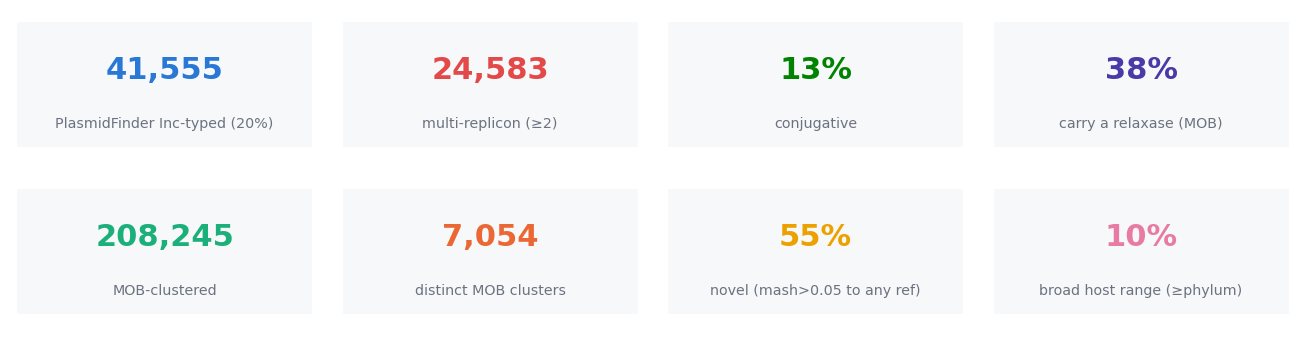

In [3]:
def stat_tiles(items, ncol=4, figsize=(12, 3.2)):
    nrow = int(np.ceil(len(items)/ncol)); fig, ax = plt.subplots(nrow, ncol, figsize=figsize)
    ax = np.atleast_1d(ax).ravel()
    for a, (big, lab, col) in zip(ax, items):
        a.axis("off"); a.add_patch(plt.Rectangle((0.02, 0.08), 0.96, 0.84, transform=a.transAxes, facecolor="#f7f8fa", edgecolor="none"))
        a.text(0.5, 0.60, big, transform=a.transAxes, ha="center", va="center", fontsize=20, fontweight="bold", color=col)
        a.text(0.5, 0.24, lab, transform=a.transAxes, ha="center", va="center", fontsize=9.3, color=MUTED)
    for a in ax[len(items):]:
        a.axis("off")
    fig.tight_layout(); return fig

tiles = [
    (f"{(M.pf_inc_types!='').sum():,}", "PlasmidFinder Inc-typed (20%)", PAL[0]),
    (f"{(M.pf_n_inc>=2).sum():,}", "multi-replicon (≥2)", PAL[5]),
    (f"{(D.predicted_mobility=='conjugative').mean()*100:.0f}%", "conjugative", PAL[3]),
    (f"{D.has_relaxase.mean()*100:.0f}%", "carry a relaxase (MOB)", PAL[4]),
    (f"{D.primary_cluster_id.replace('-','').ne('').sum():,}", "MOB-clustered", PAL[1]),
    (f"{D.loc[D.primary_cluster_id!='-','primary_cluster_id'].nunique():,}", "distinct MOB clusters", PAL[7]),
    (f"{(D.mash_neighbor_distance>0.05).mean()*100:.0f}%", "novel (mash>0.05 to any ref)", PAL[2]),
    (f"{(D.hr_rank.isin(['phylum','multi-phylla'])).mean()*100:.0f}%", "broad host range (≥phylum)", PAL[6]),
]
fig = stat_tiles(tiles); save(fig, "00_glance"); plt.show()

## 1 · Replicon / Inc typing (PlasmidFinder)

Standard-threshold replicon calls and the Inc-family landscape. Combined with MOB-suite and PLSDB,
replicon coverage reaches 46% (up from the 12% PLSDB baseline). Col and the IncF complex dominate.

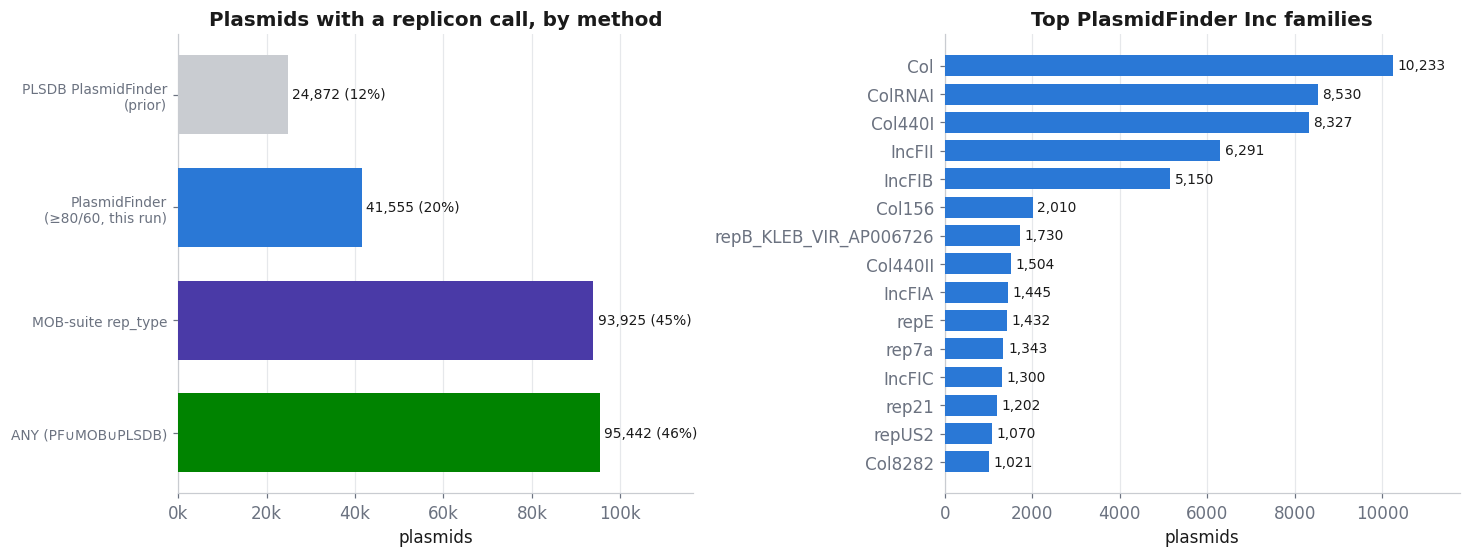

In [4]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 5.2))

methods = {
    "PLSDB PlasmidFinder\n(prior)": (M.plsdb_inc_types != "").sum(),
    "PlasmidFinder\n(≥80/60, this run)": (M.pf_inc_types != "").sum(),
    "MOB-suite rep_type": (D.rep != "").sum(),
    "ANY (PF∪MOB∪PLSDB)": ((M.pf_inc_types != "") | (M.mob_rep_types != "") | (M.plsdb_inc_types != "")).sum(),
}
s = pd.Series(methods)
a1.barh(range(len(s))[::-1], s.values, color=[LGREY, PAL[0], PAL[4], PAL[3]], height=0.7, zorder=3)
a1.set_yticks(range(len(s))[::-1]); a1.set_yticklabels(s.index, fontsize=9)
for i, v in zip(range(len(s))[::-1], s.values):
    a1.text(v + max(s.values)*0.01, i, f"{v:,} ({100*v/n:.0f}%)", va="center", ha="left", fontsize=9, color=INK)
a1.set_xlim(0, max(s.values)*1.22); a1.set_title("Plasmids with a replicon call, by method"); a1.set_xlabel("plasmids")
a1.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a1.grid(axis="y", visible=False)

fam = pd.Series(multi_count(M.pf_inc_families)).sort_values().tail(15)
a2.barh(fam.index, fam.values, color=PAL[0], height=0.74, zorder=3); hbar_labels(a2, fam.values)
a2.set_title("Top PlasmidFinder Inc families"); a2.set_xlabel("plasmids"); a2.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "01_replicon_coverage"); plt.show()

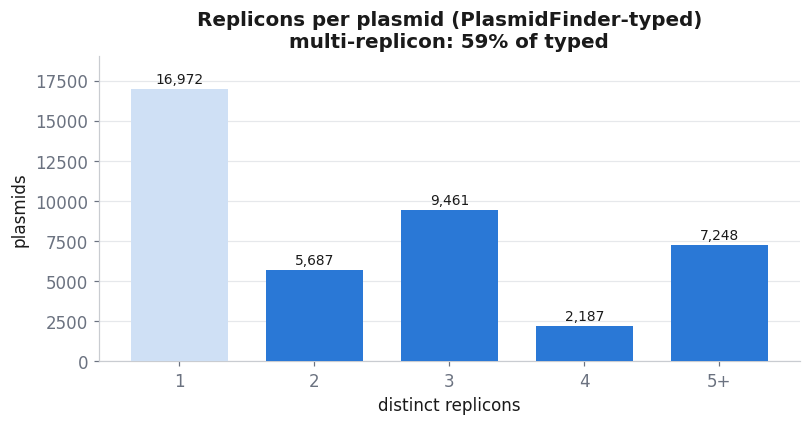

In [5]:
# multi-replicon distribution (PlasmidFinder-typed)
typed = M[M.pf_n_inc > 0]
vc = typed.pf_n_inc.clip(upper=5).value_counts().sort_index()
lab = {1: "1", 2: "2", 3: "3", 4: "4", 5: "5+"}
multi = (typed.pf_n_inc >= 2).mean()*100
fig, ax = plt.subplots(figsize=(7.5, 4))
bars = ax.bar([lab[k] for k in vc.index], vc.values, color=["#cfe0f5" if k == 1 else PAL[0] for k in vc.index], width=0.72, zorder=3)
for b, v in zip(bars, vc.values):
    ax.text(b.get_x()+b.get_width()/2, v+max(vc.values)*0.01, f"{v:,}", ha="center", va="bottom", fontsize=9, color=INK)
ax.set_title(f"Replicons per plasmid (PlasmidFinder-typed)\nmulti-replicon: {multi:.0f}% of typed")
ax.set_xlabel("distinct replicons"); ax.set_ylabel("plasmids"); ax.set_ylim(0, max(vc.values)*1.12); ax.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "02_multireplicon"); plt.show()

## 2 · Predicted mobility and its molecular determinants

MOB-suite predicts mobility from the machinery it detects: a **relaxase** (MOB) makes a plasmid at least
**mobilizable**; a relaxase **plus** a mating-pair-formation (MPF) system makes it **conjugative**;
neither → **non-mobilizable**. The panels below show the mobility split, the determinant logic, and the
striking size difference — conjugative plasmids are an order of magnitude larger because they carry the
conjugation apparatus.

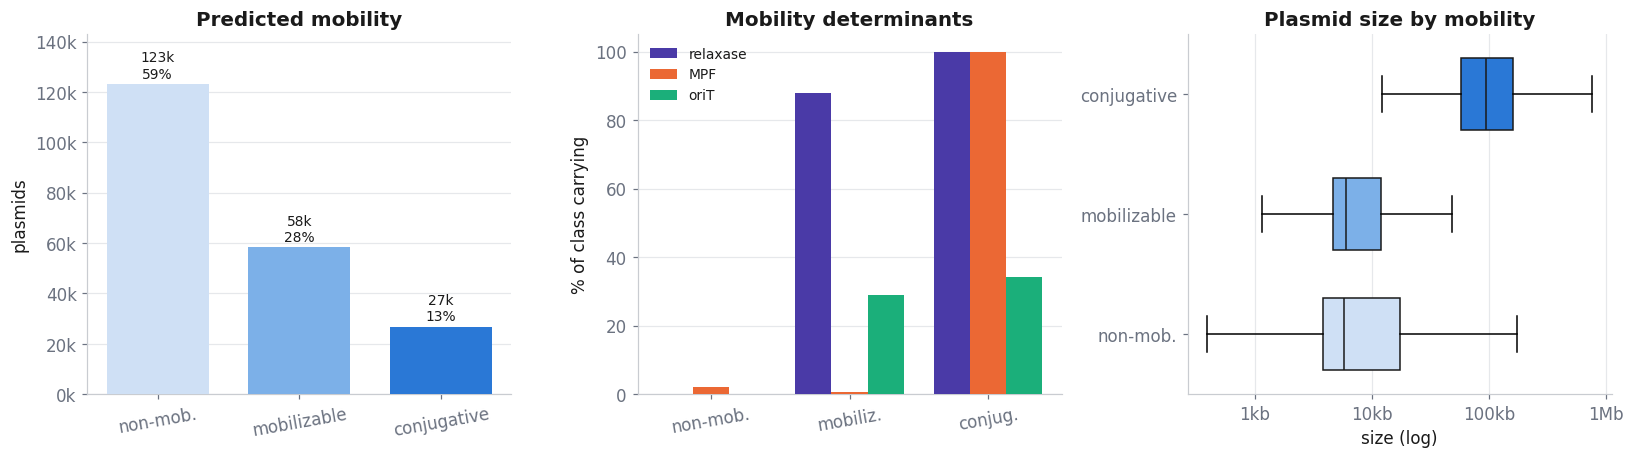

In [6]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15, 4.3))

mob = D.predicted_mobility.value_counts().reindex(MOB_ORDER)
bars = a1.bar(range(3), mob.values, color=[MOB_COL[m] for m in MOB_ORDER], width=0.72, zorder=3)
for b, v in zip(bars, mob.values):
    a1.text(b.get_x()+b.get_width()/2, v+max(mob.values)*0.01, f"{v/1000:.0f}k\n{v/len(D)*100:.0f}%", ha="center", va="bottom", fontsize=9, color=INK)
a1.set_xticks(range(3)); a1.set_xticklabels(["non-mob.", "mobilizable", "conjugative"], rotation=10)
a1.set_title("Predicted mobility"); a1.set_ylabel("plasmids"); a1.set_ylim(0, max(mob.values)*1.16)
a1.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a1.grid(axis="x", visible=False)

# determinant presence per mobility class
det = pd.DataFrame({
    "relaxase": D.groupby("predicted_mobility").has_relaxase.mean().reindex(MOB_ORDER)*100,
    "MPF": D.groupby("predicted_mobility").has_mpf.mean().reindex(MOB_ORDER)*100,
    "oriT": D.groupby("predicted_mobility").has_orit.mean().reindex(MOB_ORDER)*100})
x = np.arange(3); w = 0.26
for i, (c, col) in enumerate(zip(["relaxase", "MPF", "oriT"], [PAL[4], PAL[7], PAL[1]])):
    a2.bar(x + (i-1)*w, det[c].values, w, label=c, color=col, zorder=3)
a2.set_xticks(x); a2.set_xticklabels(["non-mob.", "mobiliz.", "conjug."], rotation=10)
a2.set_ylabel("% of class carrying"); a2.set_title("Mobility determinants"); a2.legend(fontsize=9); a2.grid(axis="x", visible=False)

data = [np.log10(D.loc[D.predicted_mobility == m, "size"].dropna()) for m in MOB_ORDER]
bp = a3.boxplot(data, vert=False, patch_artist=True, widths=0.6, showfliers=False)
for patch, m in zip(bp["boxes"], MOB_ORDER):
    patch.set_facecolor(MOB_COL[m]); patch.set_edgecolor(INK)
for med in bp["medians"]:
    med.set_color(INK)
a3.set_yticklabels(["non-mob.", "mobilizable", "conjugative"])
a3.set_xticks([3, 4, 5, 6]); a3.set_xticklabels(["1kb", "10kb", "100kb", "1Mb"])
a3.set_title("Plasmid size by mobility"); a3.set_xlabel("size (log)"); a3.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "03_mobility_determinants_size"); plt.show()

## 3 · Conjugation systems — relaxase × MPF

The molecular pairing that defines a conjugative plasmid: its **relaxase (MOB)** family and its
**mating-pair-formation (MPF)** type. The heatmap shows which combinations co-occur across conjugative
plasmids — e.g. MOBF+MPF_F (the IncF paradigm) and MOBP+MPF_T/MPF_I.

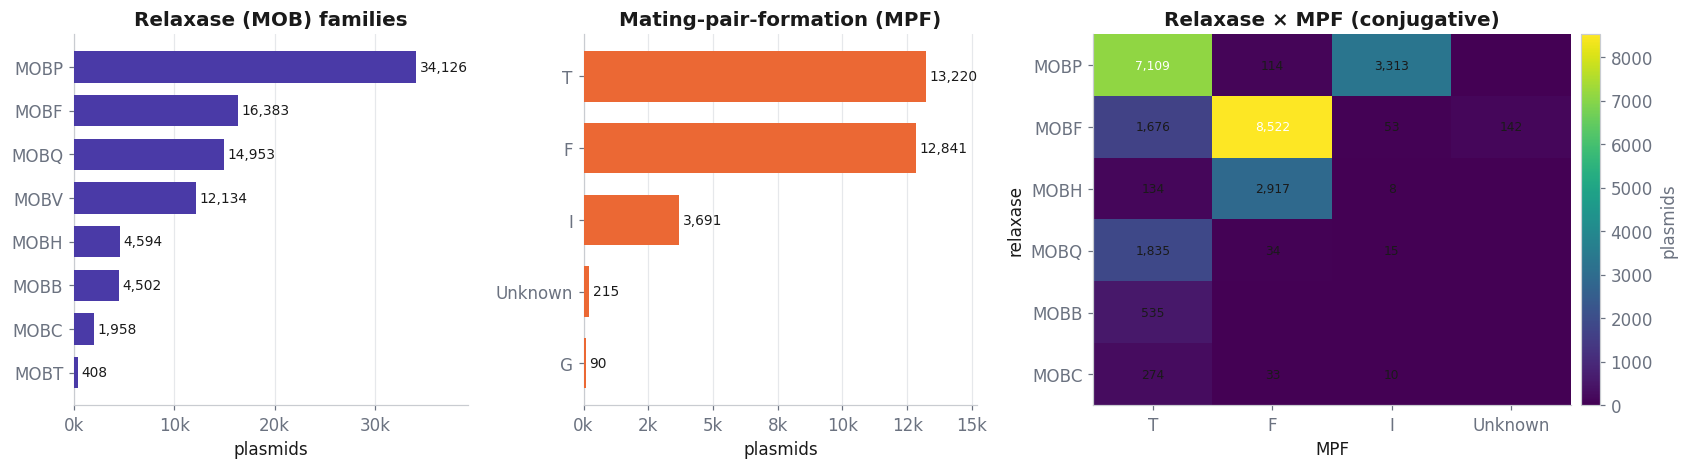

In [7]:
fig, (a1, a2, a3) = plt.subplots(1, 3, figsize=(15.5, 4.4), gridspec_kw={"width_ratios": [1, 1, 1.3]})

rel = pd.Series(multi_count(D.relaxase, sep=",")).sort_values().tail(8)
a1.barh(rel.index, rel.values, color=PAL[4], height=0.72, zorder=3); hbar_labels(a1, rel.values)
a1.set_title("Relaxase (MOB) families"); a1.set_xlabel("plasmids")
a1.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a1.grid(axis="y", visible=False)

mpf = D.loc[D.has_mpf, "mpf_type"].str.replace("MPF_", "", regex=False).str.title().value_counts().head(6).sort_values()
a2.barh(mpf.index, mpf.values, color=PAL[7], height=0.7, zorder=3); hbar_labels(a2, mpf.values)
a2.set_title("Mating-pair-formation (MPF)"); a2.set_xlabel("plasmids")
a2.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a2.grid(axis="y", visible=False)

# relaxase (primary) x MPF among conjugative
C = D[D.predicted_mobility == "conjugative"].copy()
C["mob1"] = C.relaxase.str.split(",").str[0]
C["mpf1"] = C.mpf_type.str.replace("MPF_", "", regex=False)
top_mob = C.mob1.value_counts().head(6).index
top_mpf = C.mpf1.value_counts().head(4).index
ct = pd.crosstab(C.mob1, C.mpf1).reindex(index=top_mob, columns=top_mpf).fillna(0)
im = a3.imshow(ct.values, cmap=SEQ, aspect="auto")
a3.set_xticks(range(len(top_mpf))); a3.set_xticklabels(top_mpf); a3.set_yticks(range(len(top_mob))); a3.set_yticklabels(top_mob)
for i in range(ct.shape[0]):
    for j in range(ct.shape[1]):
        v = int(ct.values[i, j])
        if v:
            a3.text(j, i, f"{v:,}", ha="center", va="center", fontsize=8,
                    color="white" if v > ct.values.max()*0.5 else INK)
a3.set_title("Relaxase × MPF (conjugative)"); a3.set_xlabel("MPF"); a3.set_ylabel("relaxase"); a3.grid(False)
fig.colorbar(im, ax=a3, pad=0.02, fraction=0.046).set_label("plasmids", color=MUTED)
fig.tight_layout(); save(fig, "04_conjugation_systems"); plt.show()

## 4 · MOB clusters

`mob_typer` assigns every plasmid to a **primary cluster** (a mash-based plasmid taxonomy) and a finer
**secondary cluster**. Cluster sizes are heavily skewed — a few large clusters and a long tail of small
ones/singletons.

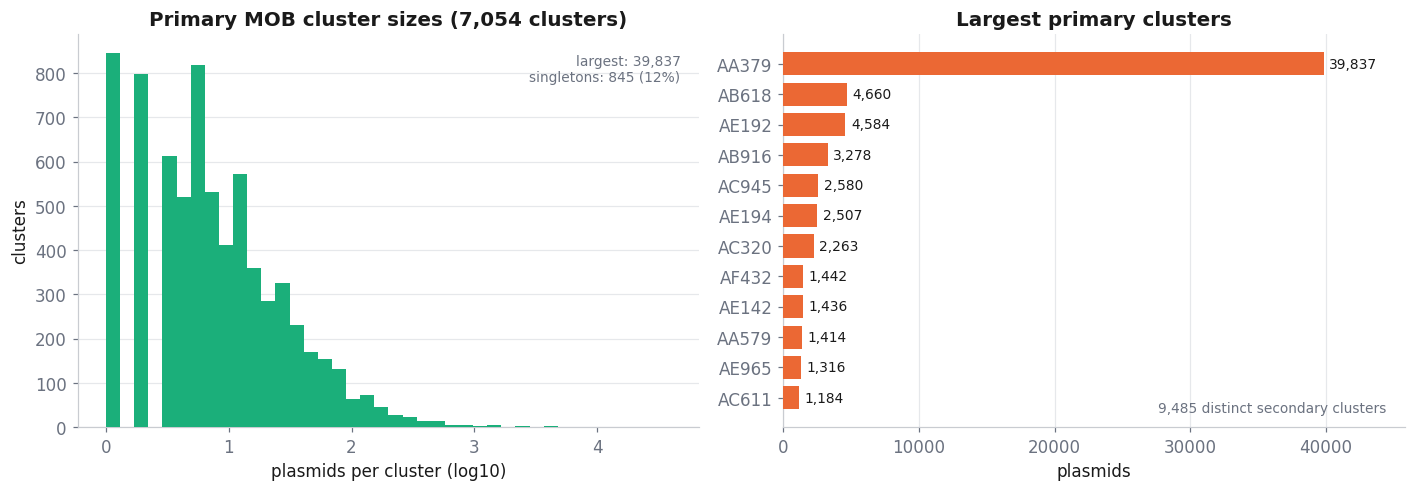

In [8]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
prim = D.loc[D.primary_cluster_id != "-", "primary_cluster_id"].value_counts()
a1.hist(np.log10(prim.values), bins=40, color=PAL[1], zorder=3)
a1.set_title(f"Primary MOB cluster sizes ({len(prim):,} clusters)")
a1.set_xlabel("plasmids per cluster (log10)"); a1.set_ylabel("clusters")
a1.text(0.97, 0.95, f"largest: {prim.max():,}\nsingletons: {(prim==1).sum():,} ({100*(prim==1).mean():.0f}%)",
        transform=a1.transAxes, ha="right", va="top", fontsize=9, color=MUTED); a1.grid(axis="x", visible=False)

top = prim.head(12).sort_values()
a2.barh(top.index, top.values, color=PAL[7], height=0.76, zorder=3); hbar_labels(a2, top.values)
a2.set_title("Largest primary clusters"); a2.set_xlabel("plasmids"); a2.grid(axis="y", visible=False)
sec = D.loc[D.secondary_cluster_id != "-", "secondary_cluster_id"].nunique()
a2.text(0.97, 0.03, f"{sec:,} distinct secondary clusters", transform=a2.transAxes, ha="right", va="bottom", fontsize=9, color=MUTED)
fig.tight_layout(); save(fig, "05_clusters"); plt.show()

## 5 · Predicted host range & breadth

The predicted host range and, importantly, its **taxonomic rank** — how *broad* the prediction is
(genus = narrow → multi-phyla = very broad). Enterobacterales and the gut anaerobe *Bacteroides* lead;
a substantial fraction are predicted broad-host-range.

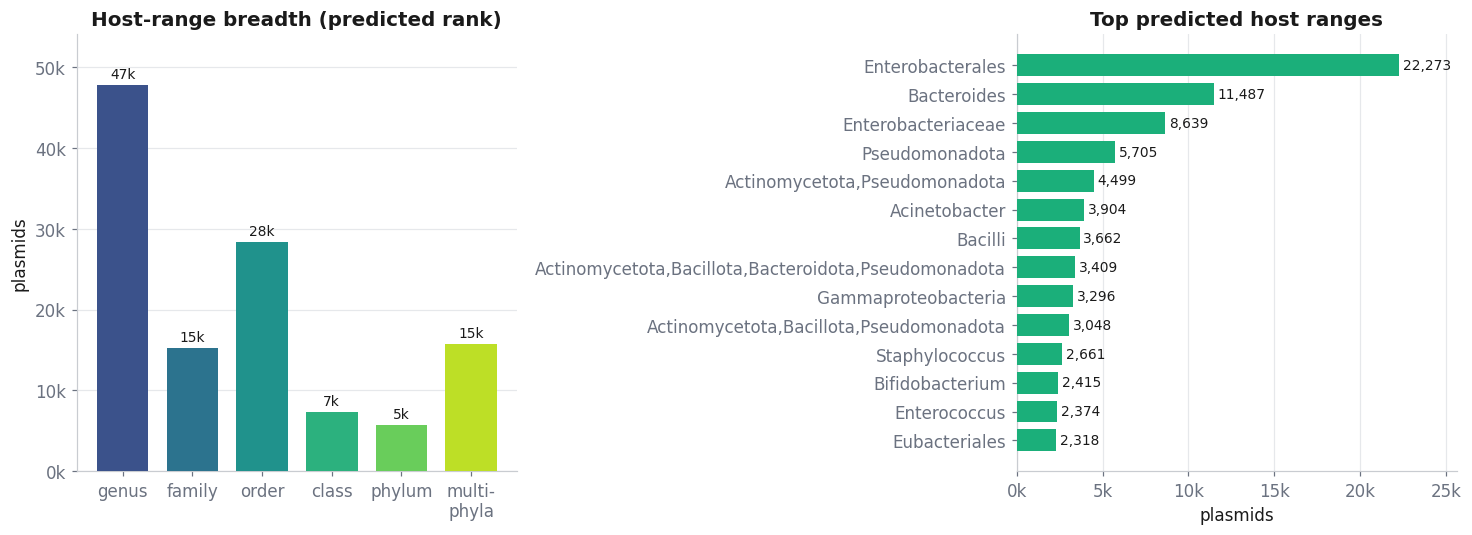

In [9]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13.5, 5))
RANKS = ["genus", "family", "order", "class", "phylum", "multi-phylla"]
rk = D.loc[D.hr_rank.isin(RANKS), "hr_rank"].value_counts().reindex(RANKS).fillna(0)
# sequential narrow->broad ramp
ramp = plt.get_cmap(SEQ)(np.linspace(0.25, 0.9, len(RANKS)))
bars = a1.bar(range(len(RANKS)), rk.values, color=ramp, width=0.74, zorder=3)
for b, v in zip(bars, rk.values):
    a1.text(b.get_x()+b.get_width()/2, v+max(rk.values)*0.01, f"{int(v/1000)}k", ha="center", va="bottom", fontsize=9, color=INK)
a1.set_xticks(range(len(RANKS))); a1.set_xticklabels(["genus", "family", "order", "class", "phylum", "multi-\nphyla"])
a1.set_title("Host-range breadth (predicted rank)"); a1.set_ylabel("plasmids")
a1.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a1.set_ylim(0, max(rk.values)*1.13); a1.grid(axis="x", visible=False)

hr = D.loc[D.hr_name != "", "hr_name"].value_counts().head(14).sort_values()
a2.barh(hr.index, hr.values, color=PAL[1], height=0.76, zorder=3); hbar_labels(a2, hr.values)
a2.set_title("Top predicted host ranges"); a2.set_xlabel("plasmids")
a2.xaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a2.grid(axis="y", visible=False)
fig.tight_layout(); save(fig, "06_hostrange"); plt.show()

## 6 · Sequence novelty

`mash_neighbor_distance` is the Mash distance from each plasmid to its nearest neighbour in MOB-suite's
reference set — a proxy for how novel the sequence is. **~55% sit >0.05 from any reference**, reflecting
the metagenomic reach of the working set (a large fraction are not close to known isolate plasmids).

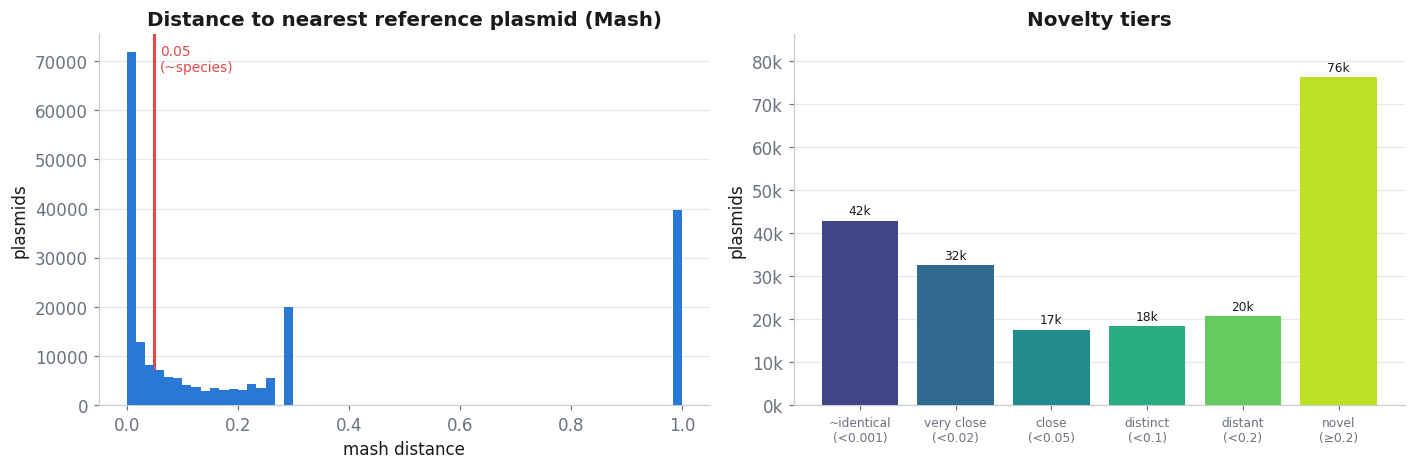

In [10]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.4))
d = D.mash_neighbor_distance.dropna()
a1.hist(d, bins=60, color=PAL[0], zorder=3)
a1.axvline(0.05, color=PAL[5], lw=2); a1.text(0.06, a1.get_ylim()[1]*0.9, "0.05\n(~species)", color=PAL[5], fontsize=9)
a1.set_title("Distance to nearest reference plasmid (Mash)"); a1.set_xlabel("mash distance"); a1.set_ylabel("plasmids"); a1.grid(axis="x", visible=False)

bins = [0, 0.001, 0.02, 0.05, 0.1, 0.2, 1.01]
labs = ["~identical\n(<0.001)", "very close\n(<0.02)", "close\n(<0.05)", "distinct\n(<0.1)", "distant\n(<0.2)", "novel\n(≥0.2)"]
cat = pd.cut(d, bins=bins, labels=labs, right=False).value_counts().reindex(labs)
ramp = plt.get_cmap(SEQ)(np.linspace(0.2, 0.9, len(labs)))
bars = a2.bar(range(len(labs)), cat.values, color=ramp, width=0.8, zorder=3)
for b, v in zip(bars, cat.values):
    a2.text(b.get_x()+b.get_width()/2, v+max(cat.values)*0.01, f"{int(v/1000)}k", ha="center", va="bottom", fontsize=8, color=INK)
a2.set_xticks(range(len(labs))); a2.set_xticklabels(labs, fontsize=8)
a2.set_title("Novelty tiers"); a2.set_ylabel("plasmids")
a2.yaxis.set_major_formatter(mpl.ticker.FuncFormatter(lambda x, _: f"{x/1000:.0f}k")); a2.set_ylim(0, max(cat.values)*1.13); a2.grid(axis="x", visible=False)
fig.tight_layout(); save(fig, "07_novelty"); plt.show()

## 7 · Summary & data dictionary

**Headline findings (MOB-suite)**

- **Mobility follows the machinery**: ~59% non-mobilizable, ~28% mobilizable (relaxase, no MPF), ~13%
  conjugative (relaxase + MPF). Determinant panel confirms the logic cleanly.
- **Conjugative plasmids are ~16× larger** (median ~95 kb vs ~6 kb) — they carry the conjugation apparatus.
- **Conjugation systems**: relaxases led by MOBP/MOBF/MOBQ/MOBV; MPF by MPF_T/MPF_F/MPF_I; the dominant
  pairings are MOBF+MPF_F (IncF paradigm) and MOBP+MPF_T/MPF_I.
- **Clusters**: 7,000+ primary MOB clusters (9,485 secondary), heavily skewed with many singletons.
- **Host range**: Enterobacterales & *Bacteroides* lead; breadth spans genus→multi-phyla, a sizeable
  broad-host-range fraction.
- **Novelty**: ~55% of plasmids are >0.05 Mash from any reference — the working set reaches well beyond
  known isolate plasmids.
- **Replicons (PlasmidFinder ≥80/60)**: 20% typed, 24,583 multi-replicon; Col & IncF families dominate.

**Typing columns in the master + `mob_full.tsv.gz`**

| column | meaning |
|---|---|
| `pf_inc_types` / `pf_inc_families` / `pf_n_inc` | PlasmidFinder replicon alleles / families / count |
| `mob_rep_types`, `mob_relaxase`, `mob_mpf`, `mob_orit` | MOB-suite replicon / relaxase / MPF / oriT |
| `mob_mobility` | non-mobilizable / mobilizable / conjugative |
| `mob_cluster`, secondary_cluster_id | MOB primary / secondary cluster |
| `mob_host_range`, hr_rank | predicted host range + its taxonomic breadth |
| `mash_neighbor_distance` | distance to nearest reference plasmid (novelty proxy) |

*Generated by `scripts/build_typing_notebook.py`; MOB-suite output aggregated by
`scripts/aggregate_mob_full.py`; typing via `scripts/mobtyper_array.sbatch` +
`scripts/plasmidfinder_run.sbatch`. Method: `reports/typing_methodology.md`. Figures in
`reports/figures/typing/`.*